# ICMS 150 (April 4)

- **Combined_Pattern_Registrations.pkl**: including electrical stimulation pattern informations, the same format as the one I shared before with you.
- **All_Shank_Spk_Vecs.npy**: spiking events from each neuron. The same format as previous. Sampling frequency: 30K
- **VStim_Onset_TS.npy**: the onset timestamps of each visual stimulus trials. NOTE: These are recorded at a different sampling frequency, which is 1K. DO REMEMBER to align data in 2. and 3., they're not written under the same clock (due to hardware setup).
- **VStim_Labels.npy**: the orientation degree for each visual stimulus trials. Each degree should have 100 trials.


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 100 oracle samples repeating 10 times


In [2]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2


all_spikes = np.load("data/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json("data/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load("data/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load("data/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

In [3]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 72, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 72, 50)


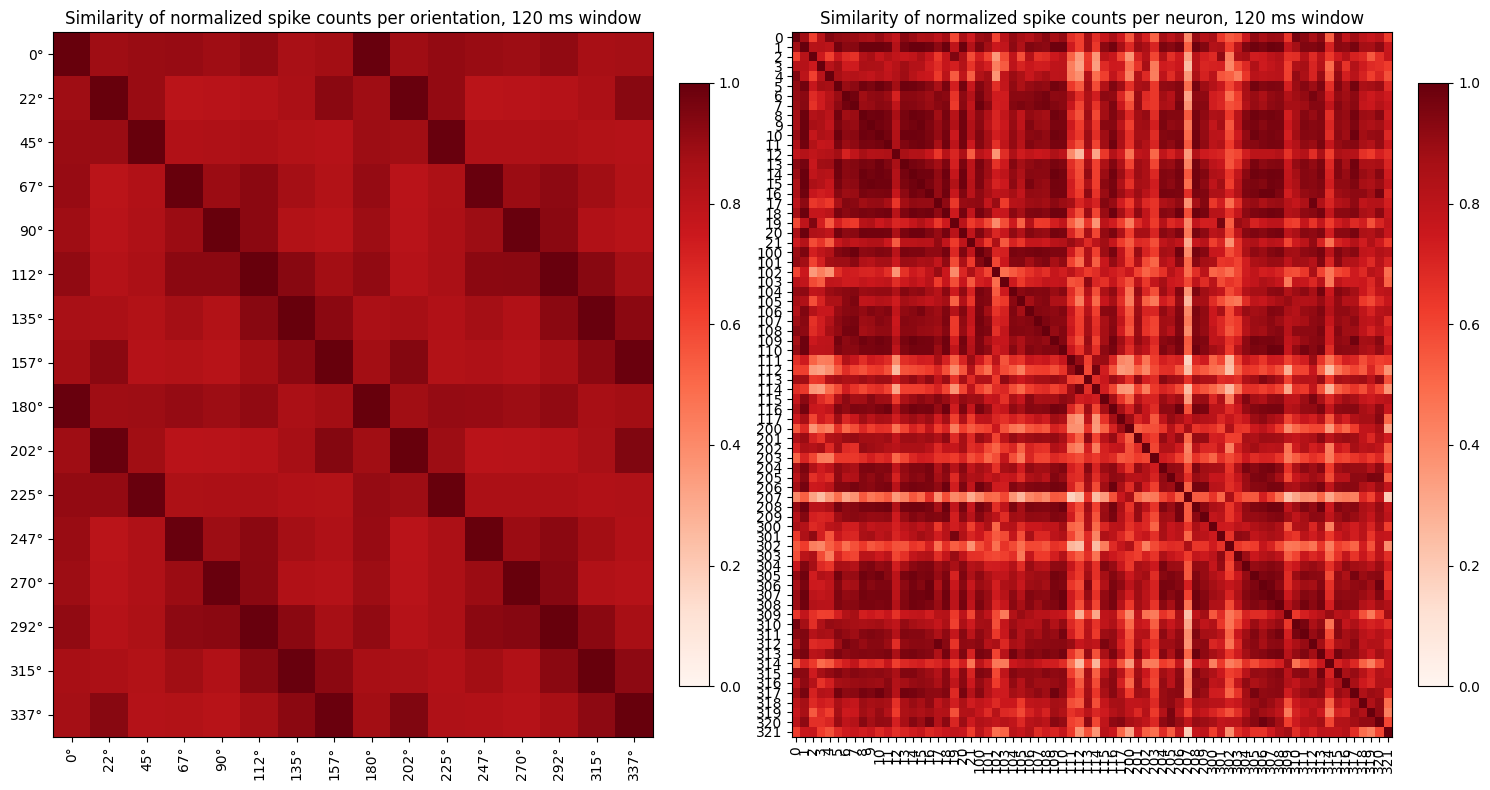

In [4]:
from sklearn.preprocessing import normalize
window = 120 # ms
orient_total = sum_responses[:, :, :window // 10].sum(axis=2)  # (n_orient, n_neurons)
normed_ori = normalize(orient_total, norm='l2')  # each row independently        # (16, n_neurons)
sim_matrix_ori = normed_ori @ normed_ori.T     

normed_neuron = normalize(orient_total.T, norm='l2').T  # each column independently      
sim_matrix_neuron = normed_neuron.T @ normed_neuron

# print (orient_total.shape)
# sim_matrix = orient_total @ orient_total.T                    # (16, 16) cosine similarities

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
im = ax[0].imshow(sim_matrix_ori, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[0].set_xticks(range(len(visual_orientation_degs)))
ax[0].set_yticks(range(len(visual_orientation_degs)))
ax[0].set_xticklabels([f'{int(d)}°' for d in visual_orientation_degs], rotation=90)
ax[0].set_yticklabels([f'{int(d)}°' for d in visual_orientation_degs])
ax[0].set_title(f'Similarity of normalized spike counts per orientation, {window} ms window')

ax[1].set_title(f'Similarity of normalized spike counts per neuron, {window} ms window')
ax[1].imshow(sim_matrix_neuron, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[1].set_xticks(range(n_neurons))
ax[1].set_yticks(range(n_neurons))
ax[1].set_xticklabels(all_neuron_ids, rotation=90)
ax[1].set_yticklabels(all_neuron_ids)   
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

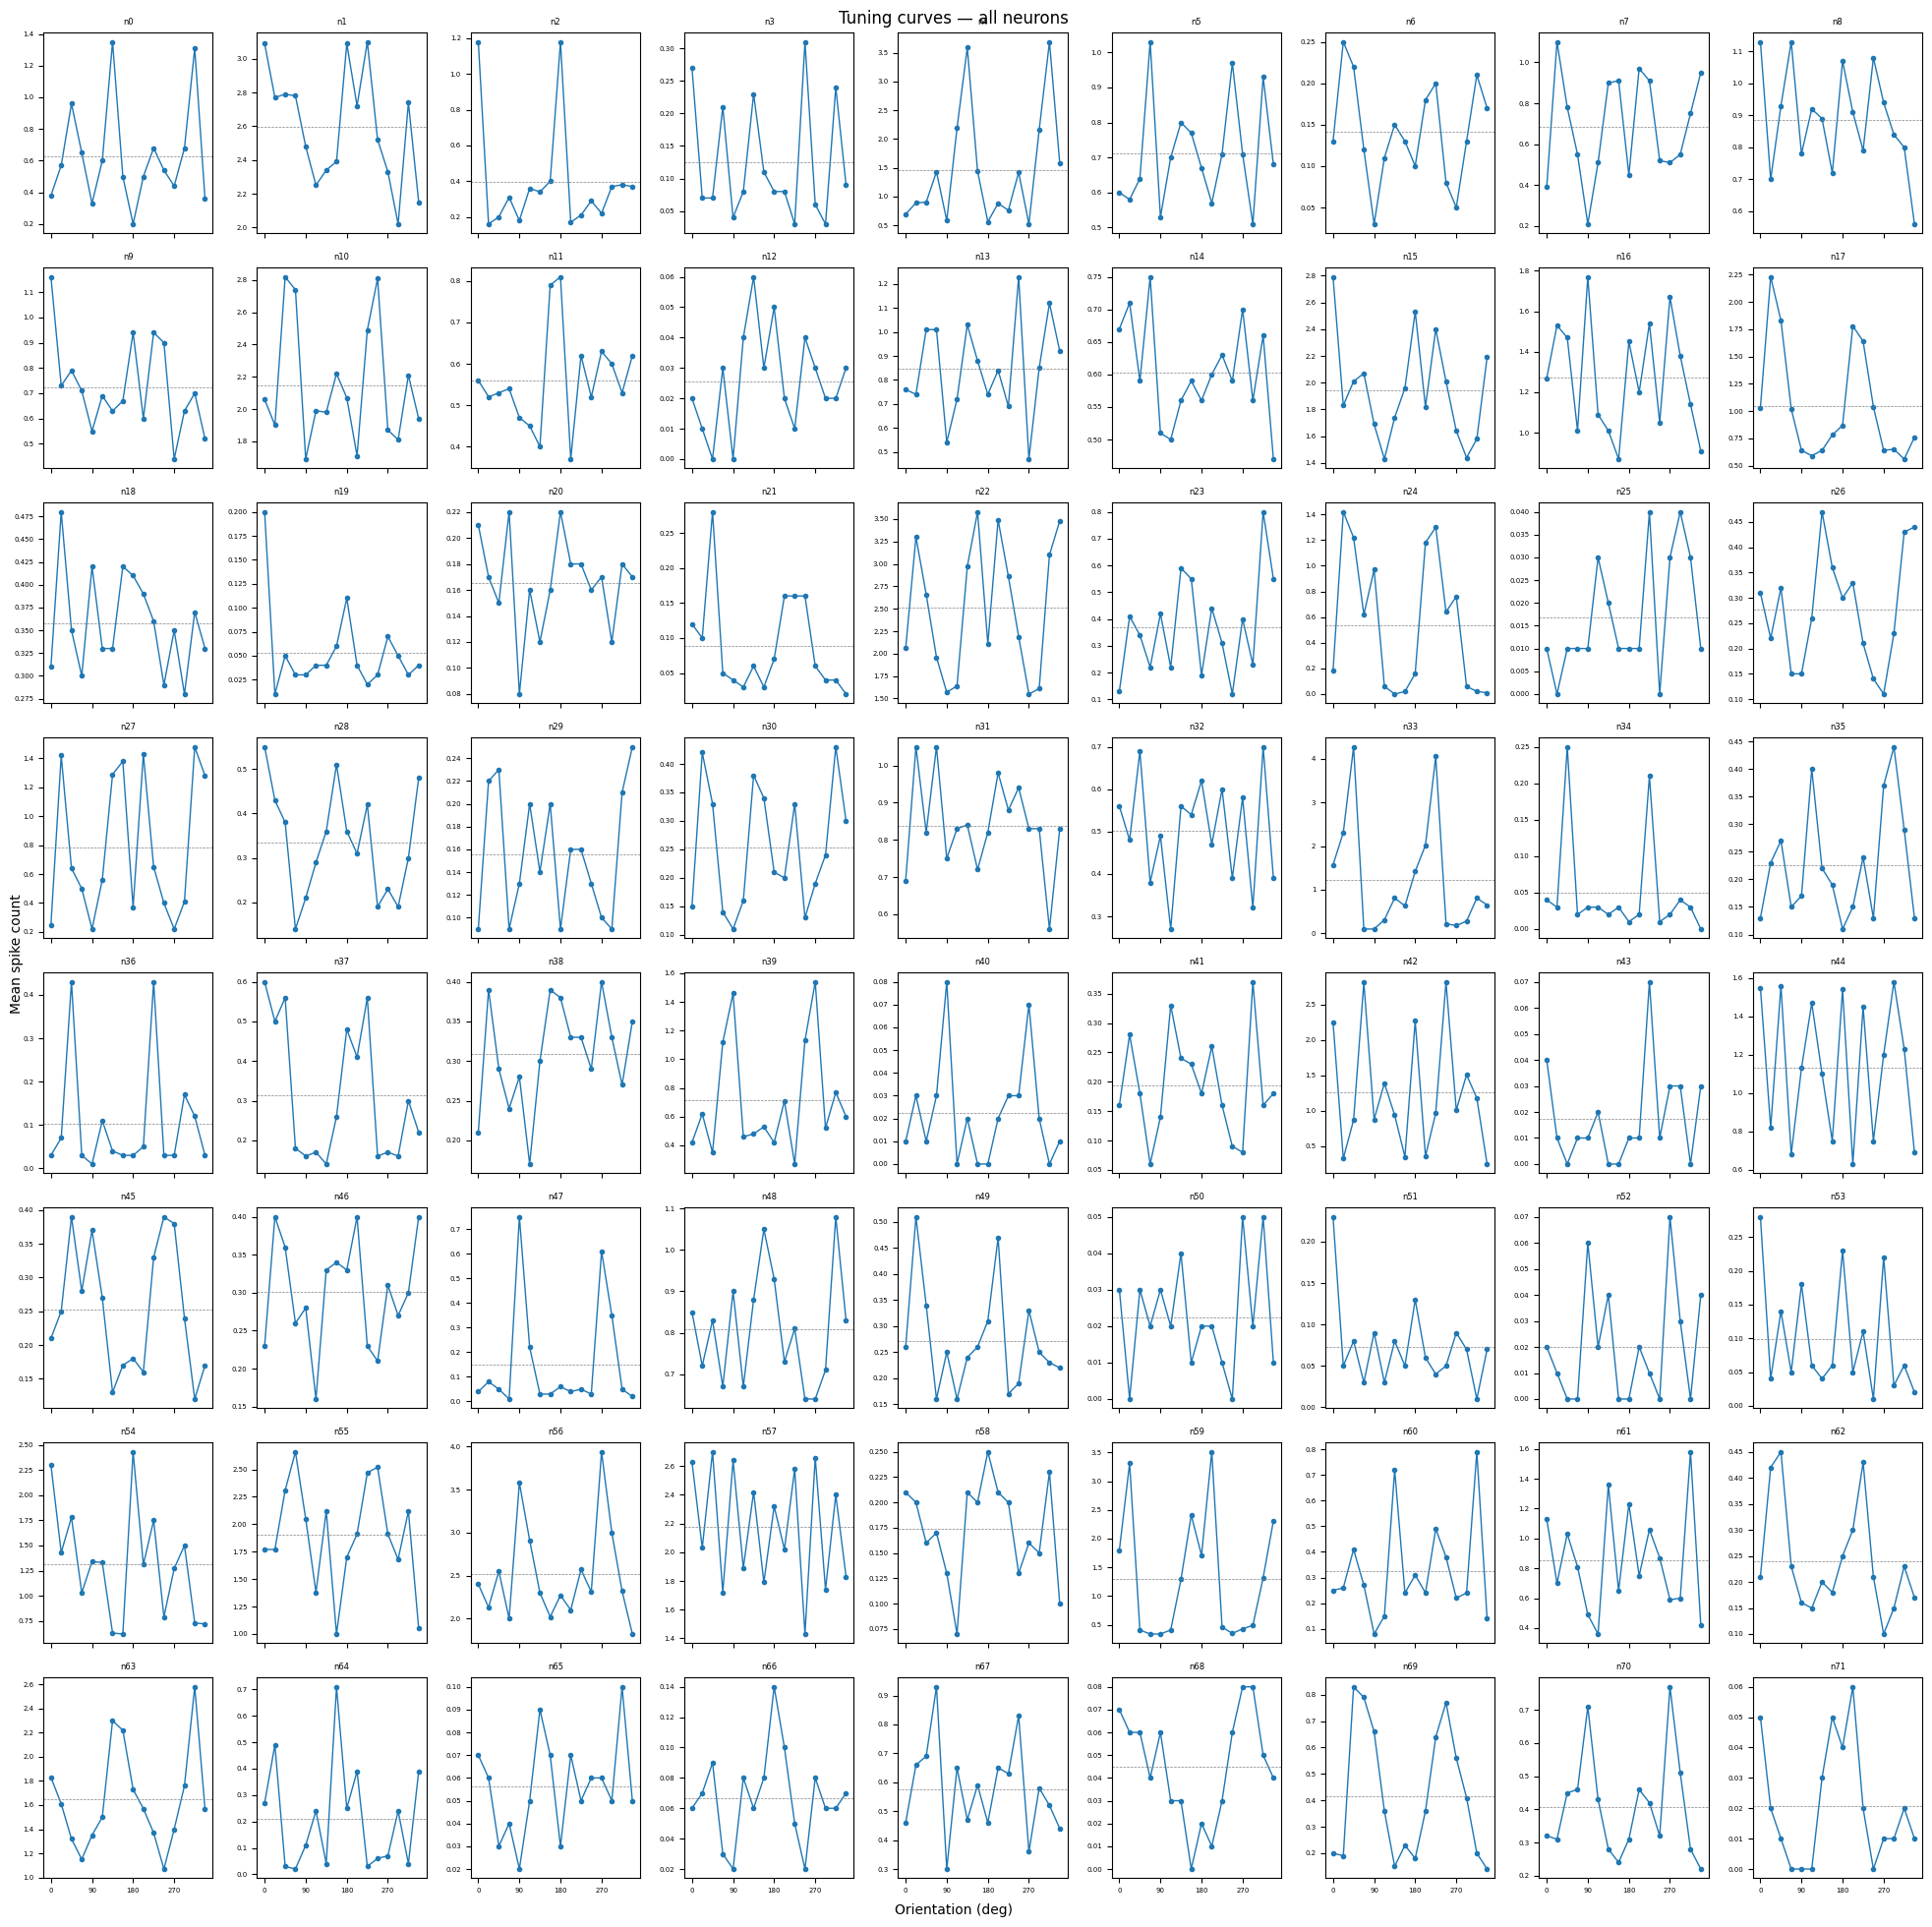

In [5]:
# Tuning curves: mean spike count per orientation, per neuron
fig, axes = plt.subplots(8, 9, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, nidx in enumerate(range(72)):
    ax = axes[i]
    ax.plot(visual_orientation_degs, orient_total[:, nidx], 'o-', ms=3, lw=1)
    ax.axhline(orient_total[:, nidx].mean(), color='gray', lw=0.5, linestyle='--')
    ax.set_title(f'n{nidx}', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_xticks(visual_orientation_degs[::4])

for ax in axes[len(range(72)):]:
    ax.set_visible(False)

fig.supxlabel('Orientation (deg)', fontsize=10)
fig.supylabel('Mean spike count', fontsize=10)
fig.suptitle(f'Tuning curves — all neurons', fontsize=12)
plt.tight_layout()
plt.show()


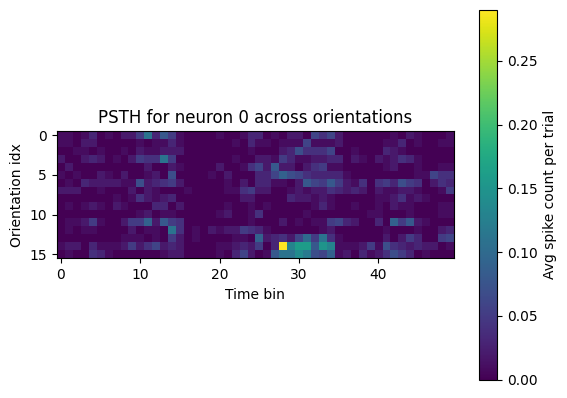

In [6]:
plt.imshow(sum_responses[:, 3, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title("PSTH for neuron 0 across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

In [7]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)
pca3 = PCA(n_components=2)
pca3.fit(X)
proj, _ = np.linalg.qr(np.array([
    mean_vec[0],
    pca3.components_[0],
    pca3.components_[1],
]).T)                                       # (n_neurons, 3)

coords = X @ proj                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    name='Individual trials',
    hovertemplate='trial<extra></extra>',
    showlegend=True,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Orientation average',
))

fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.show()


In [8]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
DATADIR = 'data'
pattern_df_raw = read_pattern_json(f'{DATADIR}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 72
Unique patterns: 3100, Total trials: 4000


In [9]:
# ============================================================
# Train SimpleCausalSpikeCNN on stim->spike prediction.
#   - inputs : per-electrode current ('current' encoding), 10 ms bins, +-3 amps
#   - targets: per-neuron spike counts, 10 ms bins
#   - train  : non-oracle trials (90/10 train/val split)
#   - test   : oracle trials
#   - stim channels only (no init state, no spike history)
#   - checkpoints + config + history saved to vis_stim/results/<run_name>/
# ============================================================
import os, sys, json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils  import BinnedStimSpikeDataset
from models import SimpleCausalSpikeCNN, train_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print('device:', device)
MAX_TIME_MS = 600
# --- config ---
# Best config from local_arch_full sweep (2026-05-11_18-45-53):
#   test_corr = 0.2185 +- 0.0004 (n=10 seeds)
CFG = dict(
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    N_INPUT_BINS  = MAX_TIME_MS // 10,
    N_OUTPUT_BINS = MAX_TIME_MS // 10,
    MAX_TIME_MS   = MAX_TIME_MS,
    ENCODING_MODE = 'current',
    BATCH_SIZE    = 16,
    N_EPOCHS      = 50,
    LR            = 3e-3,
    WEIGHT_DECAY  = 1e-5,
    VAL_FRAC      = 0.2,
    SEED          = 42,
    CONV_CHANNELS = [256, 256],
    KERNEL_SIZES  = [5, 3],
    FC_DIMS       = [512],
    DROPOUT       = 0.3,
)

# --- output directory ---
os.makedirs('results', exist_ok=True)
run_name = time.strftime('%Y%m%d_%H%M%S') + '_simple_cnn'
run_dir  = os.path.join('results', run_name)
os.makedirs(run_dir, exist_ok=True)
print('run dir:', run_dir)

# --- datasets (non-oracle -> train+val, oracle -> test) ---
torch.manual_seed(CFG['SEED']); np.random.seed(CFG['SEED'])

train_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=train_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)
test_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=test_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)

# 90/10 train/val split of the non-oracle set.
n_total = len(train_ds)
perm = np.random.RandomState(CFG['SEED']).permutation(n_total)
n_val = max(1, int(n_total * CFG['VAL_FRAC']))
val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

# encoding_mode='current' returns int64 amplitudes (+-3); the model expects floats
# when the embedding layer is disabled. Cast in collate_fn.
def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

NUM_WORKERS = 0  # avoid macOS spawn pickling issues with cell-local collate fn
train_loader = DataLoader(Subset(train_ds, tr_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(Subset(train_ds, val_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
print(f'train: {len(tr_idx)}  val: {len(val_idx)}  test: {len(test_ds)}')

# --- model: stim-only, no embedding ---
model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=CFG['N_INPUT_BINS'],
    n_output_bins=CFG['N_OUTPUT_BINS'],
    embedding_dim=1,                       # no embedding -> input passes through as-is
    conv_channels=CFG['CONV_CHANNELS'],
    kernel_sizes=CFG['KERNEL_SIZES'],
    fc_dims=CFG['FC_DIMS'],
    dropout=CFG['DROPOUT'],
    use_batch_norm=True,
    use_init_state=False,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model params: {n_params:,}')

# --- training ---
# Build neuron weights from variance (all neurons, top ones get higher weight)
neuron_var = orient_total.var(axis=0)                          # (n_neurons,)
neuron_weights = np.sqrt(neuron_var) / np.sqrt(neuron_var).sum()   # soft normalization
neuron_weights_t = torch.tensor(neuron_weights, dtype=torch.float32).to(device)  # (n_neurons,)

base_criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')


optimizer = torch.optim.Adam(model.parameters(), lr=CFG['LR'], weight_decay=CFG['WEIGHT_DECAY'])

best_val = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_corr': []}
ckpt_best = os.path.join(run_dir, 'best.pth')
ckpt_last = os.path.join(run_dir, 'last.pth')

for epoch in range(1, CFG['N_EPOCHS'] + 1):
    train_loss = train_epoch(model, train_loader, base_criterion, optimizer, device,
                             grad_clip=True, max_norm=1.0)
    val_loss, val_corr = validate(model, val_loader, base_criterion, device)
    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_corr'].append(float(val_corr))
    print(f'epoch {epoch:>3}/{CFG["N_EPOCHS"]}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  val_corr={val_corr:.4f}')

    torch.save(model.state_dict(), ckpt_last)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), ckpt_best)
        print(f'  [save] new best val={best_val:.4f}')

# --- final test on oracle trials (best ckpt) ---
model.load_state_dict(torch.load(ckpt_best, map_location=device))
test_loss, test_corr = validate(model, test_loader, base_criterion, device)
print(f'\noracle test loss: {test_loss:.4f}  test corr: {test_corr:.4f}')

# --- persist run metadata ---
CFG['n_stim_channels'] = int(n_stim_channels)
CFG['n_neurons']       = int(n_neurons)
CFG['n_train']         = len(tr_idx)
CFG['n_val']           = len(val_idx)
CFG['n_test']          = len(test_ds)
CFG['best_val_loss']   = float(best_val)
CFG['test_loss']       = float(test_loss)
CFG['test_corr']       = float(test_corr)
with open(os.path.join(run_dir, 'config.json'), 'w') as f:
    json.dump(CFG, f, indent=2)
with open(os.path.join(run_dir, 'history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('saved config + history to', run_dir)


device: cuda
run dir: results/20260512_114211_simple_cnn
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
train: 2400  val: 600  test: 1000
model params: 417,864


epoch   1/50  train=0.2593  val=0.2320  val_corr=0.1972
  [save] new best val=0.2320


epoch   2/50  train=0.2293  val=0.2211  val_corr=0.2560
  [save] new best val=0.2211


epoch   3/50  train=0.2221  val=0.2155  val_corr=0.2810
  [save] new best val=0.2155


epoch   4/50  train=0.2180  val=0.2145  val_corr=0.2993
  [save] new best val=0.2145


...

epoch  47/50  train=0.2043  val=0.2013  val_corr=0.3602
  [save] new best val=0.2013


epoch  48/50  train=0.2042  val=0.2015  val_corr=0.3575


epoch  49/50  train=0.2042  val=0.2015  val_corr=0.3575


epoch  50/50  train=0.2040  val=0.2014  val_corr=0.3588



oracle test loss: 0.2260  test corr: 0.2575
saved config + history to results/20260512_114211_simple_cnn


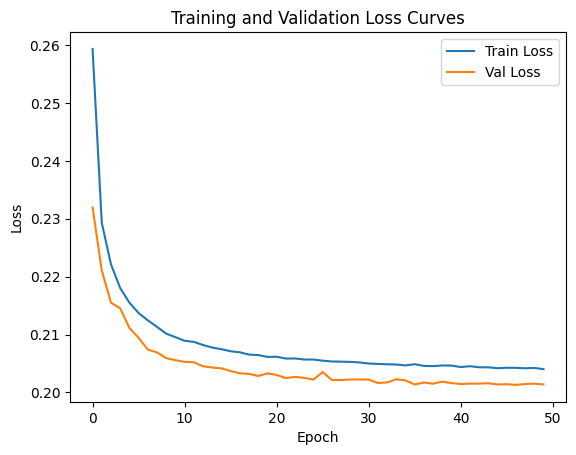

In [ ]:


plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

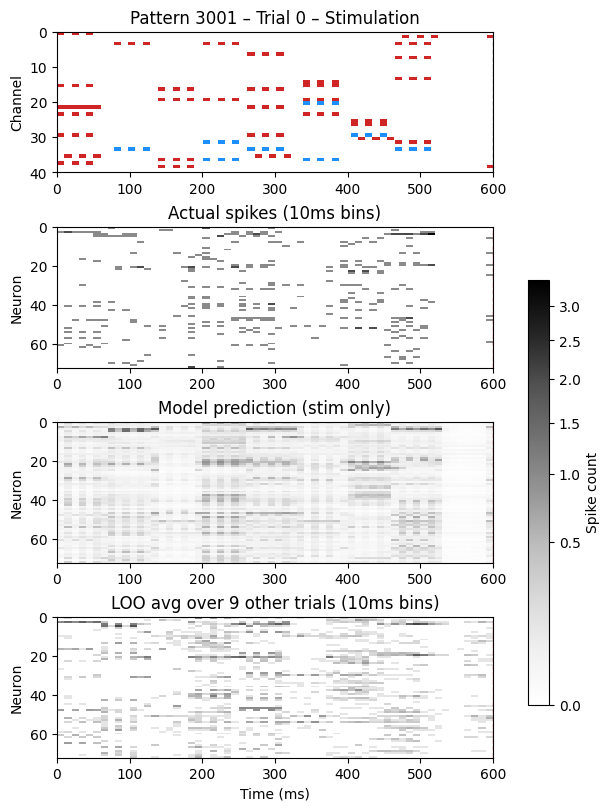

In [ ]:
# ============================================================
# Visualize one trained CNN test example (oracle pattern), reusing
# patterns_5k/viz.py:plot_single_oracle_trial.
#
# Panels: stim polarity, actual spikes, model prediction, LOO trial average.
# ============================================================
import numpy as np
import torch
from viz import plot_single_oracle_trial

# Build the cfg + raw_data dicts the viz function expects.
cfg = dict(
    input_bin_size_ms  = CFG['INPUT_BIN_MS'],
    output_bin_size_ms = CFG['OUTPUT_BIN_MS'],
    n_input_bins       = CFG['N_INPUT_BINS'],
    n_output_bins      = CFG['N_OUTPUT_BINS'],
    max_time_ms        = CFG['MAX_TIME_MS'],
    output_offset      = 0,
    history            = 0,
    init_state         = False,
    encoding_mode      = CFG['ENCODING_MODE'],
)
raw_data = dict(
    pattern_df         = pattern_df,
    spike_responses    = spike_responses,
    pattern_polarities = pattern_polarities,
)
model_tuple = (model, base_criterion, device)

# Pick the first oracle pattern with at least 2 trials so LOO is meaningful.
unique_oracle = pattern_df[pattern_df['is_oracle']][['pattern_name', 'pattern_timing_index']].drop_duplicates()
counts = unique_oracle.groupby('pattern_name').size()
PATTERN_TO_SHOW = counts[counts >= 2].index[0] if (counts >= 2).any() else counts.index[0]
TRIAL_IDX = 0

fig = plot_single_oracle_trial(
    pattern_name=PATTERN_TO_SHOW,
    trial_idx=TRIAL_IDX,
    model_tuple=model_tuple,
    cfg=cfg,
    raw_data=raw_data,
    test_loader=test_loader,
    coarse_factor=1,
)

from IPython.display import display
fig.axes[2].set_title(f'Model prediction (stim only)')
display(fig)


In [ ]:
# fixed neuron n
# a
# for trial =1:100
#    for time = 1: 1
#         samples_response(trial, neuron n, time) = sample_poisson(TCN(stim(1:time, observed responses(trial, [1:n] U [n+1:N], 1: time-1), samples_response(trial, n, 1: time-1))))

# for each neuron, use the Pillow 2008 method to causally compute a stimulus response from the TCN model
neuron = 0
n_trials = 100
stim_pattern = pattern_stims[0]  # shape (n_trials, n_time_bins, n_channels)
samples_response = np.zeros((n_trials, n_neurons, N_OUTPUT_BINS))  # shape (n_trials, n_neurons, n_time_bins)

for trial in range(n_trials):
    for timebin in range(1, N_OUTPUT_BINS):
        past_stim = stim[trial, :timebin, :]
        past_responses = samples_response[trial, np.r_[0:neuron, neuron+1:], :timebin-1]
        current_response = samples_response[trial, neuron, :timebin-1]
        model_input = np.concatenate([past_stim, past_responses], axis=-1)
        predicted_rate = model(model_input)  # shape (timebin-1,)
        samples_response[trial, neuron, timebin] = np.random.poisson(predicted_rate[-1])

### Stim creator

In [81]:
import heapq
import numpy as np
import torch


class StimCreator():
    """Greedy stim builder. Each 60 ms step (= 6 bins of 10 ms) can hold up to
    `budget_per_step` simultaneously-active channels; for each slot we try every
    (channel, encoding) candidate and keep the one whose model prediction has the
    smallest L2 distance to `target_spikes`.

    Hardware constraint enforced during the search: channels are partitioned
    into `n_shanks` equal-sized shanks by sorted channel ID, and at most
    `max_per_shank` channels per shank may fire SIMULTANEOUSLY (same bin within
    a step). Two channels with non-overlapping delay_mode bin-sets (e.g.
    dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5}) don't conflict.

    Encoding -> (offsets within the 6-bin step, amplitude) follows
    encode_pattern_nominal_current_10ms in patterns_5k/utils.py:
        delay_mode  0 -> bins {0,2,4}, +3
        delay_mode -1 -> bins {0,2,4}, -3
        delay_mode  1 -> bins {1,3,5}, +3
        delay_mode  2 -> bins {0..5},  +3
    """

    BINS_PER_STEP = 6  # 60 ms / 10 ms

    _ENCODING_TABLE = {
         0: ([0, 2, 4],            3), # 
        -1: ([0, 2, 4],           -3),
         1: ([1, 3, 5],           3),
         2: ([0, 1, 2, 3, 4, 5],   3),
    }

    def __init__(self, model, device, channel_to_index, n_bins,
                 n_shanks=4, max_per_shank=4, proj=None):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.channel_to_index = channel_to_index
        self.n_stim_channels = len(channel_to_index)
        self.n_bins = n_bins  # total 10 ms bins in the stim window

        # Shank partition: equal-sized chunks of sorted channel IDs.
        # Map ch_index (the row in the stim array) -> shank id.
        sorted_chs = sorted(channel_to_index.keys())
        if len(sorted_chs) % n_shanks != 0:
            raise ValueError(f"cannot split {len(sorted_chs)} channels into "
                             f"{n_shanks} equal shanks")
        shank_size = len(sorted_chs) // n_shanks
        ch_to_shank_by_id = {ch: i // shank_size
                             for i, ch in enumerate(sorted_chs)}
        # channel_to_index maps channel-id -> row in stim array; invert.
        self._idx_to_shank = np.empty(self.n_stim_channels, dtype=np.int64)
        for ch_id, idx in channel_to_index.items():
            self._idx_to_shank[idx] = ch_to_shank_by_id[ch_id]
        self.n_shanks = n_shanks
        self.max_per_shank = max_per_shank

        # Precompute bin-set per encoding.
        self._enc_bins = {enc: tuple(offsets)
                          for enc, (offsets, _amp) in self._ENCODING_TABLE.items()}
        
        # Projection for distance calculation: if provided, distance is measured in the projected space.
        if proj is not None:
            self.proj = proj
        else:
            self.proj = np.eye(n_neurons, dtype=np.float32)

    def stim_sequence_from_encoding(self, encoding):
        """Return a length-6 vector for one 60 ms step at 10 ms resolution."""
        seq = np.zeros(self.BINS_PER_STEP, dtype=np.float32)
        if encoding in self._ENCODING_TABLE:
            offsets, amp = self._ENCODING_TABLE[encoding]
            for o in offsets:
                seq[o] = amp
        return seq

    def _predict(self, stim, n_bins_truncate=None):
        """stim: (n_stim_channels, n_bins) -> (n_neurons, n_bins) numpy."""
        x = torch.from_numpy(stim).unsqueeze(0).to(self.device).float()
        with torch.no_grad():
            pred = self.model(x)
        if n_bins_truncate is not None:
            pred = pred[:, :, :n_bins_truncate]
        return torch.exp(pred).cpu().numpy()[0]

    def create_stim(self, target_spikes, budget_per_step=2,
                    encodings=(-1, 0, 1, 2), channels=None,
                    require_improvement=True, verbose=False):
        """Greedily build a stim driving the model toward `target_spikes`.

        Args:
            target_spikes: (n_neurons, n_bins) target.
            budget_per_step: max channels stimulated per 60 ms step.
            encodings: encoding labels to consider per slot.
            channels: stim-channel indices to consider (default: all).
            require_improvement: if True, stop filling a step's budget once no
                candidate strictly reduces distance.

        Returns:
            created_stim: (n_stim_channels, n_bins) float32.
            final_dist:   final L2 distance of model prediction to target.
        """
        if channels is None:
            channels = list(range(self.n_stim_channels))
        else:
            channels = list(channels)

        n_steps = self.n_bins // self.BINS_PER_STEP
        created_stim = np.zeros((self.n_stim_channels, self.n_bins), dtype=np.float32)
        used_channels_per_step = [set() for _ in range(n_steps)]
        # Per-step (shank, bin)-occupancy: shank_bin_count[step][shank, bin].
        shank_bin_count = [
            np.zeros((self.n_shanks, self.BINS_PER_STEP), dtype=np.int32)
            for _ in range(n_steps)
        ]
        curr_dist = np.linalg.norm(self._predict(created_stim, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
        if verbose:
            print(f"baseline dist: {curr_dist:.4f}")

        # Precompute encoding sequences.
        enc_seqs = [(e, self.stim_sequence_from_encoding(e)) for e in encodings]

        for step in range(n_steps):
            t0 = step * self.BINS_PER_STEP
            t1 = t0 + self.BINS_PER_STEP
            occ = shank_bin_count[step]

            for _ in range(budget_per_step):
                best = None  # (dist, ch, enc, seq)
                for ch in channels:
                    if ch in used_channels_per_step[step]:
                        continue
                    shank = self._idx_to_shank[ch]
                    for enc, seq in enc_seqs:
                        # Reject any candidate that would push a (shank, bin)
                        # cell above max_per_shank for this step.
                        bins_used = self._enc_bins[enc]
                        if any(occ[shank, b] + 1 > self.max_per_shank
                               for b in bins_used):
                            continue
                        cand = created_stim.copy()
                        cand[ch, t0:t1] = seq
                        d = np.linalg.norm(self._predict(cand, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
                        if best is None or d < best[0]: # greedy comparison
                            best = (d, ch, enc, seq)

                if best is None:
                    break
                if require_improvement and best[0] >= curr_dist:
                    break

                d, ch, enc, seq = best
                created_stim[ch, t0:t1] = seq
                used_channels_per_step[step].add(ch)
                # Commit the bin occupancy for the chosen channel/encoding.
                shank = self._idx_to_shank[ch]
                for b in self._enc_bins[enc]:
                    occ[shank, b] += 1
                curr_dist = d
                if verbose:
                    print(f"  step {step}: ch={ch}, enc={enc:>2}, dist={d:.4f}")

        return created_stim, curr_dist


In [90]:
VIS_ORIENT_TIME = 600  # ms window for visual orientation decoding (from above analysis)
BUDGET = 2
targets = sum_responses[:, :, :VIS_ORIENT_TIME // 10].sum(axis=2)  # (n_orientations, n_neurons, n_bins) -> (n_orientations, n_neurons, 12) bc 10 ms bins
est_stims = []
distances = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]  # (n_neurons,)
    stim_creator = StimCreator(model, device, channel_to_index, n_bins=VIS_ORIENT_TIME // 10, proj=proj)
    created_stim, final_dist = stim_creator.create_stim(
        target_spikes=target_spikes,
        budget_per_step=BUDGET,
        encodings=[-1, 0, 1, 2],
        channels=None,
        require_improvement=True,
        verbose=True,
    )
    est_stims.append(created_stim)
    distances.append(final_dist)
    print(f"Orientation {orientation}°: final dist={final_dist:.4f}")


baseline dist: 29.7400
  step 0: ch=22, enc= 2, dist=24.4170
  step 0: ch=31, enc=-1, dist=22.2284
  step 1: ch=22, enc= 2, dist=17.3345
  step 1: ch=31, enc=-1, dist=14.9274
  step 2: ch=22, enc= 2, dist=10.2841
  step 2: ch=31, enc=-1, dist=8.1706
  step 3: ch=39, enc= 2, dist=4.9422
  step 3: ch=22, enc=-1, dist=3.7366
  step 4: ch=21, enc=-1, dist=3.3630
  step 4: ch=25, enc= 0, dist=3.3424
Orientation 0.0°: final dist=3.3424
baseline dist: 30.0763
  step 0: ch=22, enc= 2, dist=24.6666
  step 0: ch=31, enc=-1, dist=22.5362
  step 1: ch=22, enc= 2, dist=17.4486
  step 1: ch=31, enc=-1, dist=15.0979
  step 2: ch=22, enc= 2, dist=10.0534
  step 2: ch=31, enc=-1, dist=7.9510
  step 3: ch=22, enc= 2, dist=3.5910
  step 3: ch=12, enc=-1, dist=2.9071
  step 4: ch=24, enc=-1, dist=2.4901
Orientation 22.5°: final dist=2.4901
baseline dist: 29.3646
  step 0: ch=22, enc= 2, dist=24.1617
  step 0: ch=31, enc=-1, dist=21.9979
  step 1: ch=22, enc= 2, dist=17.1591
  step 1: ch=31, enc=-1, dist=1

(72, 60)


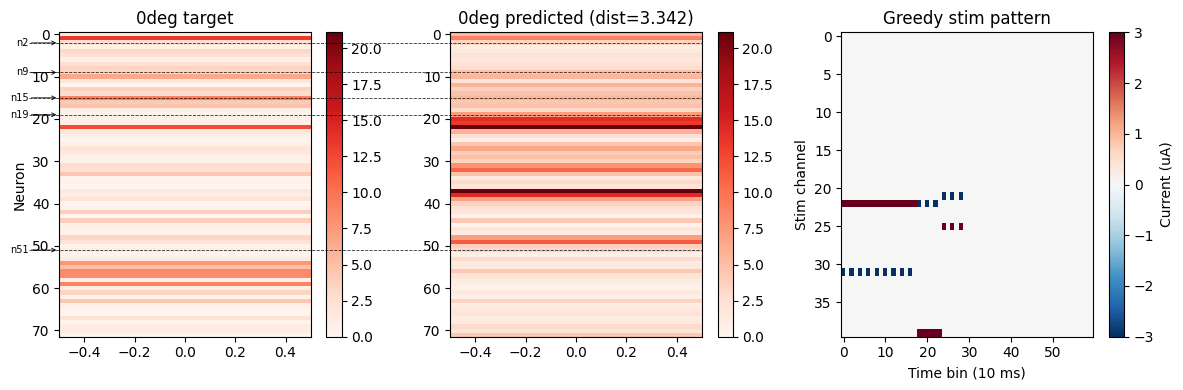

(72, 60)


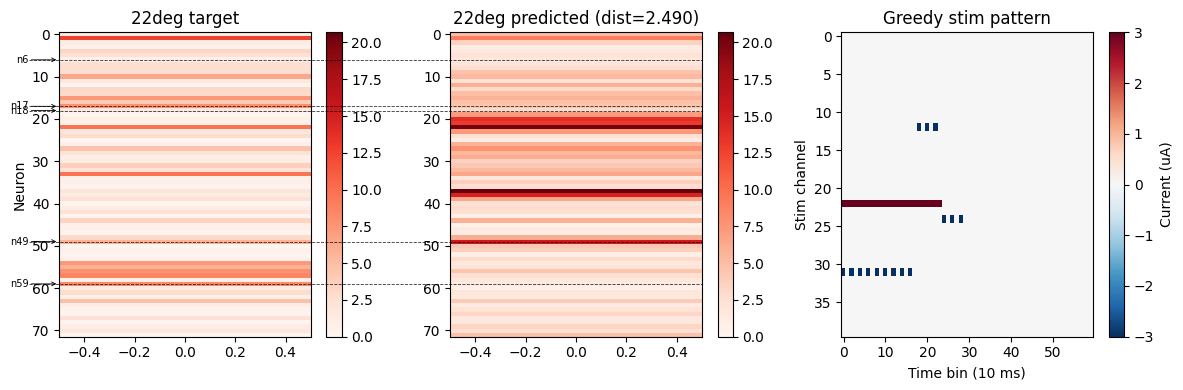

(72, 60)


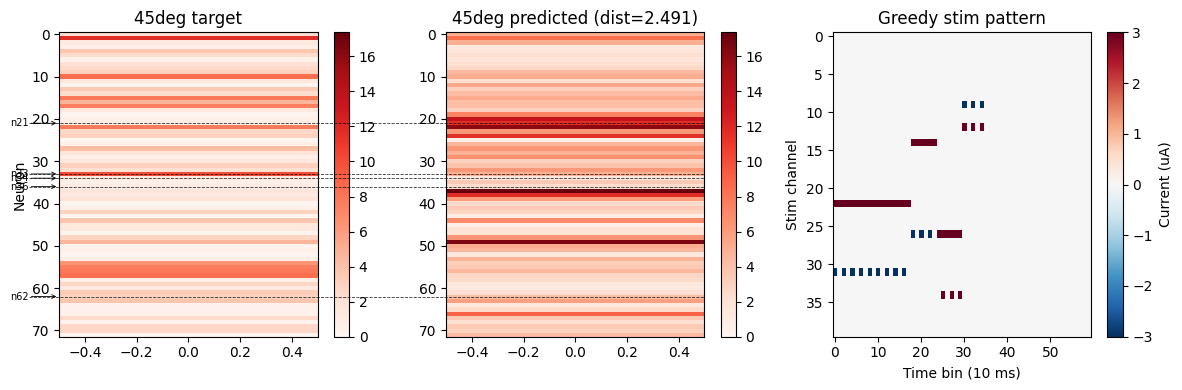

(72, 60)


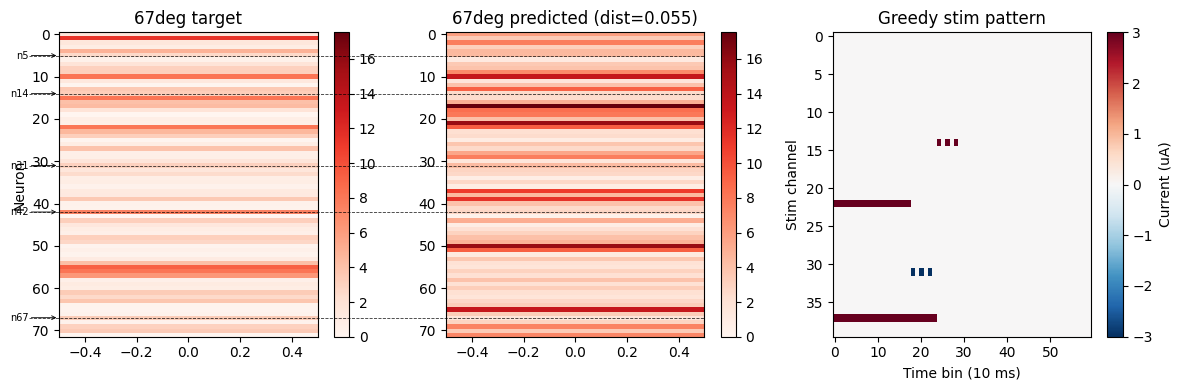

(72, 60)


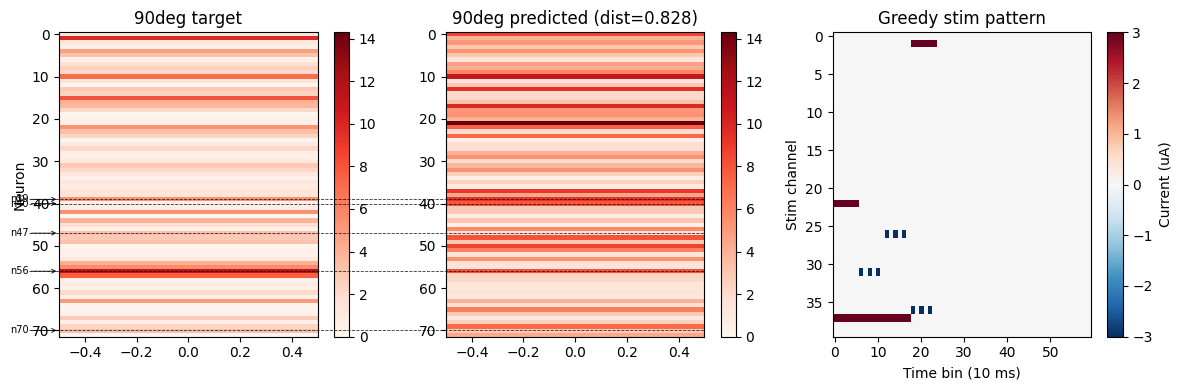

(72, 60)


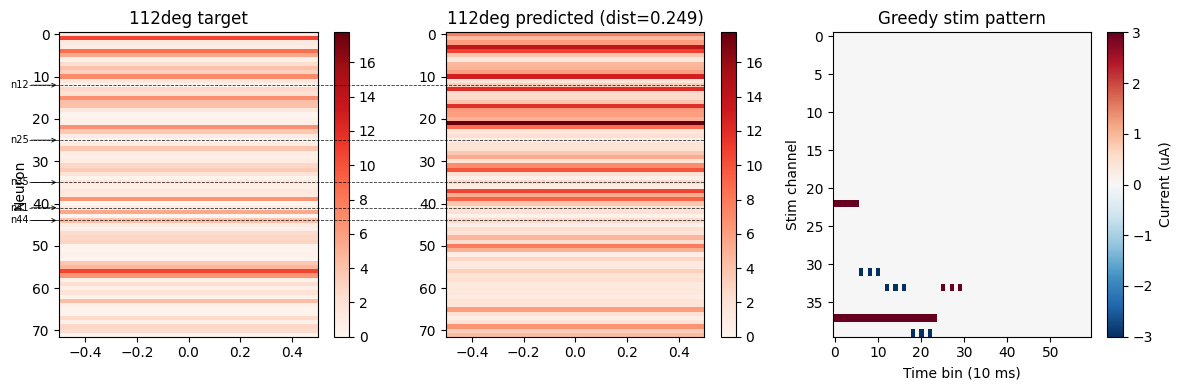

(72, 60)


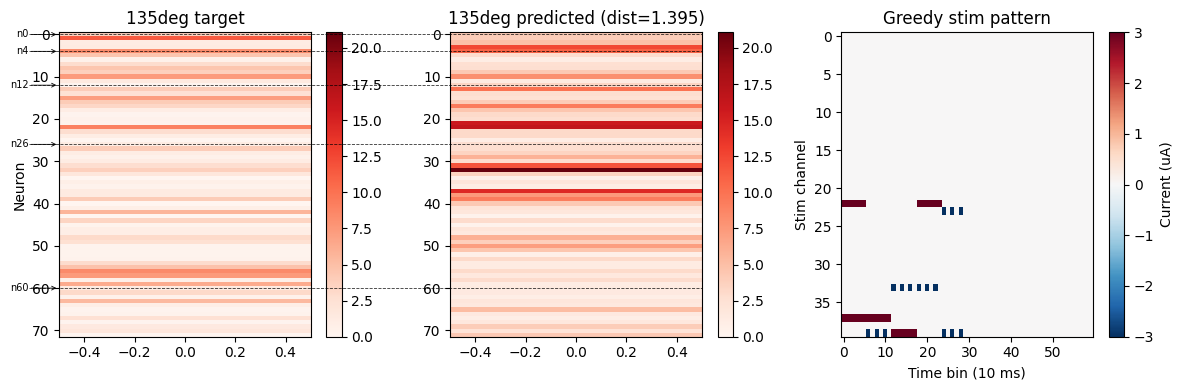

(72, 60)


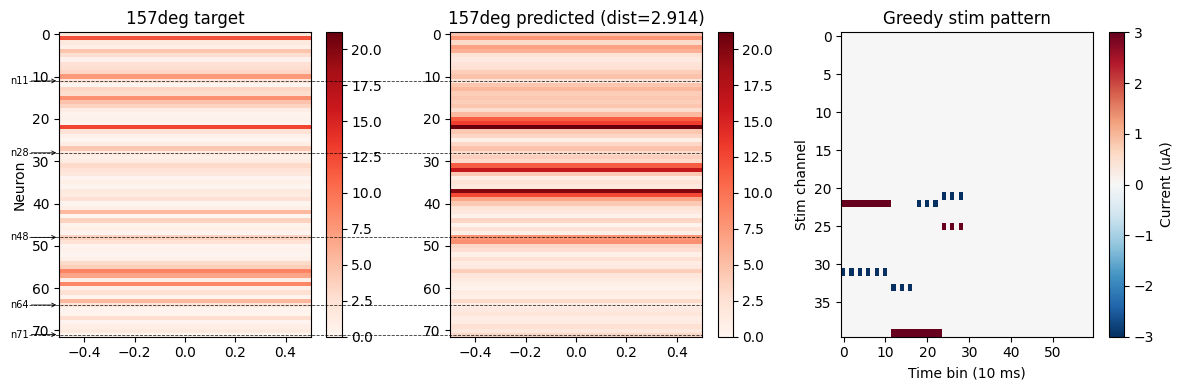

(72, 60)


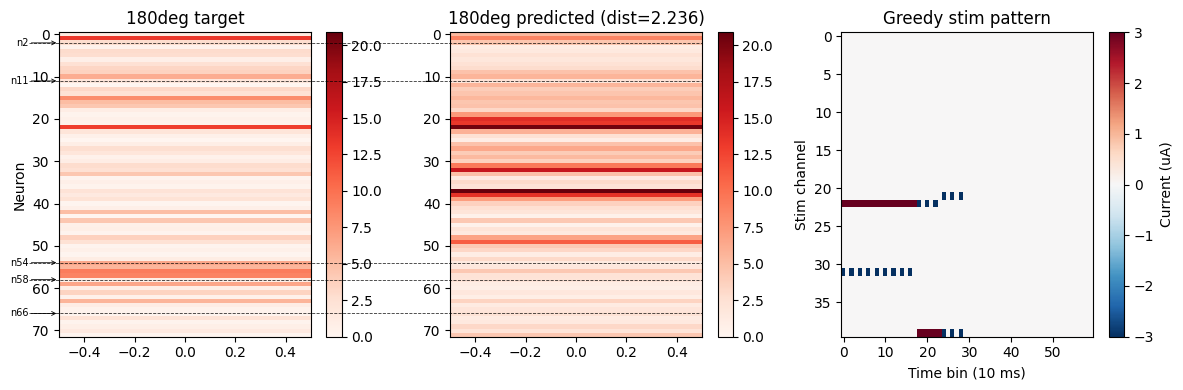

(72, 60)


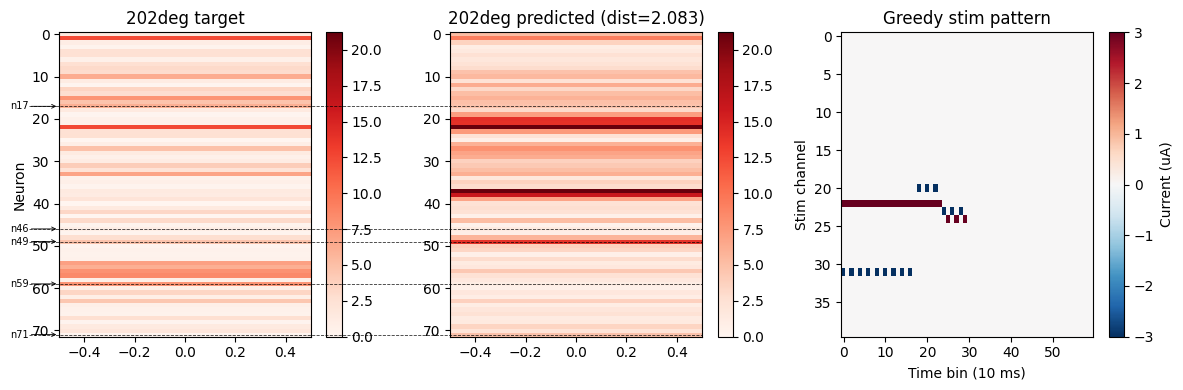

(72, 60)


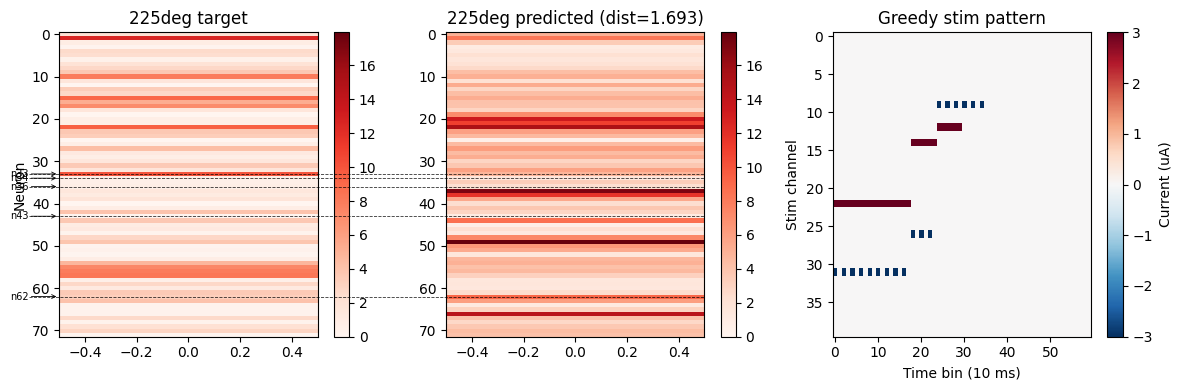

(72, 60)


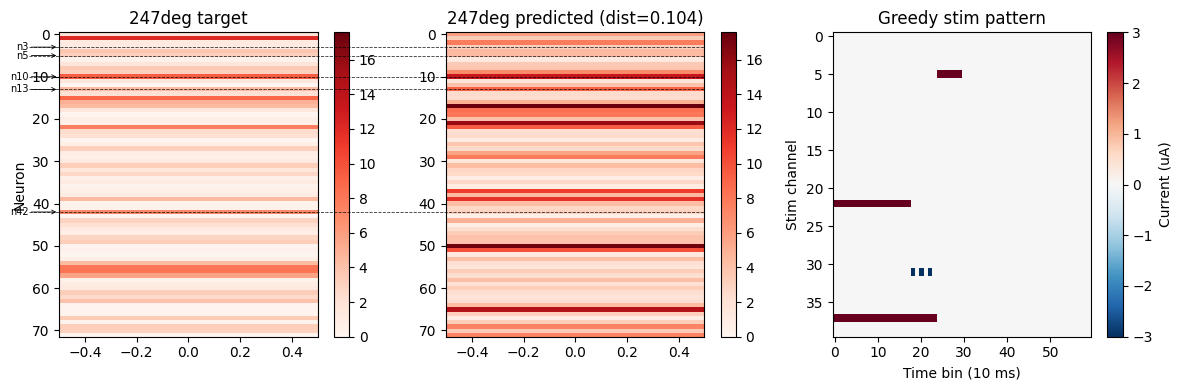

(72, 60)


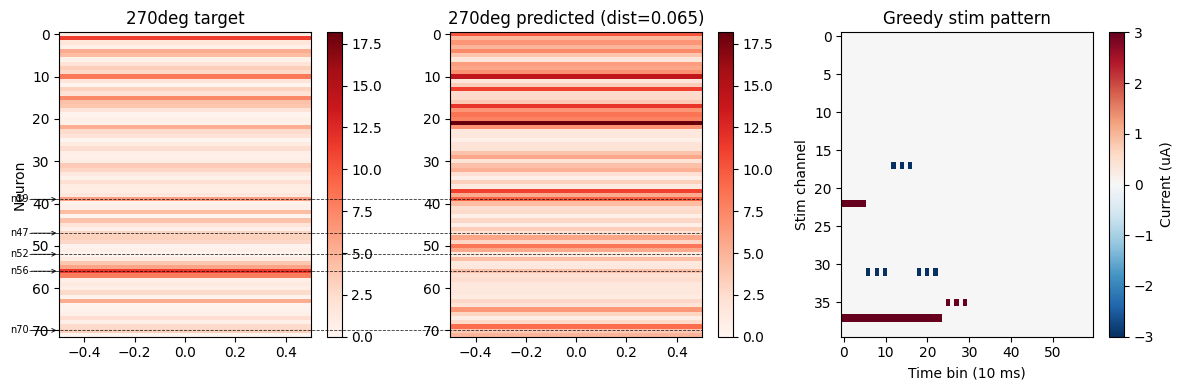

(72, 60)


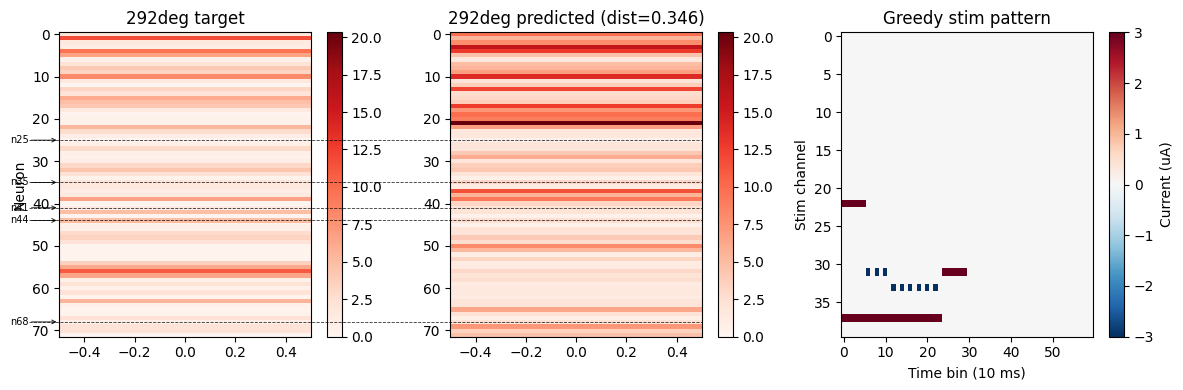

(72, 60)


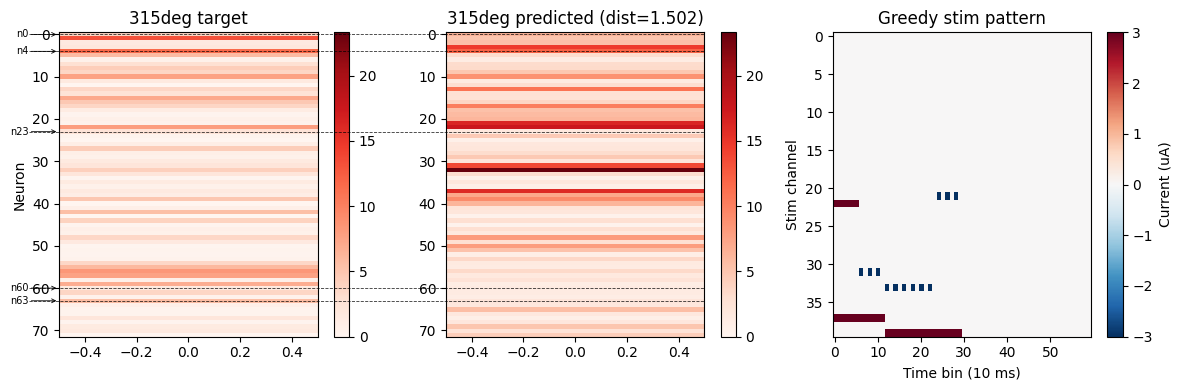

(72, 60)


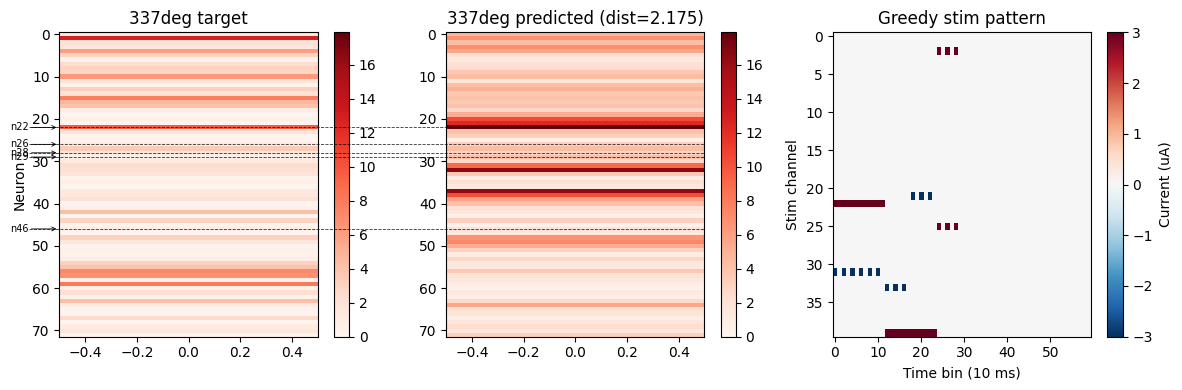

In [91]:
# Plot per orientation (3 horizontal imshow panels): target, predicted, stim.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import offset_copy

# Selectivity: per-(orient, neuron) z-score across orientations.
mu_n        = orient_total.mean(axis=0)
sigma_n     = orient_total.std(axis=0)
selectivity = (orient_total - mu_n) / (sigma_n + 1e-9)        # (n_orient, n_neurons)

ARROW_TEXT_OFFSET_PTS = -22  # matches xytext below

for o_idx, deg in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]                  # (n_neurons,)
    created_stim  = est_stims[o_idx]                # (n_stim_channels, n_bins)

    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    print (pred.shape)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,) # truncated to same window as target

    f, ax = plt.subplots(1, 3, figsize=(12, 4))
    vmax = max(np.abs(target_spikes).max(), np.abs(pred_counts).max(), 1e-6)

    ax[0].imshow(target_spikes.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[0].set_title(f'{int(deg)}deg target')
    ax[0].set_ylabel('Neuron')
    plt.colorbar(ax[0].images[0], ax=ax[0])

    # Arrow ticks for the top-5 most positively selective neurons for this
    # orientation.
    top5 = np.argsort(selectivity[o_idx])[::-1][:5]
    for nidx in top5:
        ax[0].annotate(
            f'n{int(nidx)}',
            xy=(0, nidx), xycoords=('axes fraction', 'data'),
            xytext=(ARROW_TEXT_OFFSET_PTS, 0), textcoords='offset points',
            ha='right', va='center', fontsize=7, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.6,
                            shrinkA=0, shrinkB=2),
            annotation_clip=False,
        )

    ax[1].imshow(pred_counts.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[1].set_title(f'{int(deg)}deg predicted (dist={distances[o_idx]:.3f})')
    plt.colorbar(ax[1].images[0], ax=ax[1])

    amp_max = max(np.abs(created_stim).max(), 1)
    ax[2].imshow(created_stim, aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-amp_max, vmax=amp_max)
    ax[2].set_title('Greedy stim pattern')
    ax[2].set_xlabel('Time bin (10 ms)')
    ax[2].set_ylabel('Stim channel')
    plt.colorbar(ax[2].images[0], ax=ax[2], label='Current (uA)')

    plt.tight_layout()

    # Dashed lines from each arrow's tail (label position) across the first two
    # subplots, ending at the right edge of ax[1]'s axes box.
    f.canvas.draw()
    inv = f.transFigure.inverted()
    base = ax[0].get_yaxis_transform()  # ('axes fraction', 'data')
    tail_tf = offset_copy(base, fig=f, x=ARROW_TEXT_OFFSET_PTS, y=0, units='points')
    right_tf = ax[1].get_yaxis_transform()  # ('axes fraction', 'data') for ax[1]
    for nidx in top5:
        p_left  = inv.transform(tail_tf.transform((0, nidx)))
        p_right = inv.transform(right_tf.transform((1, nidx)))
        line = Line2D([p_left[0], p_right[0]], [p_left[1], p_right[1]],
                      transform=f.transFigure, color='black',
                      linestyle='--', linewidth=0.6, alpha=0.8, zorder=10)
        f.add_artist(line)

    plt.show()


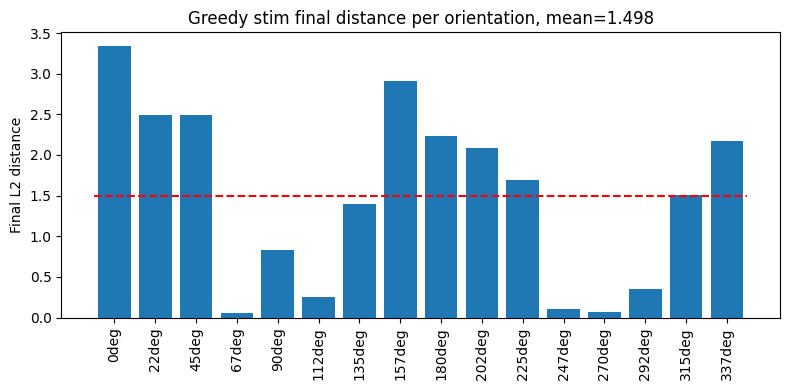

In [92]:
# Final L2 distance per orientation.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(visual_orientation_degs)), distances, color='C0')
ax.hlines(np.mean(distances), xmin=-0.5, xmax=len(visual_orientation_degs)-0.5, colors='red', linestyles='dashed', label='Mean')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_ylabel('Final L2 distance')
ax.set_title('Greedy stim final distance per orientation, mean={:.3f}'.format(np.mean(distances)))
plt.tight_layout()
plt.show()


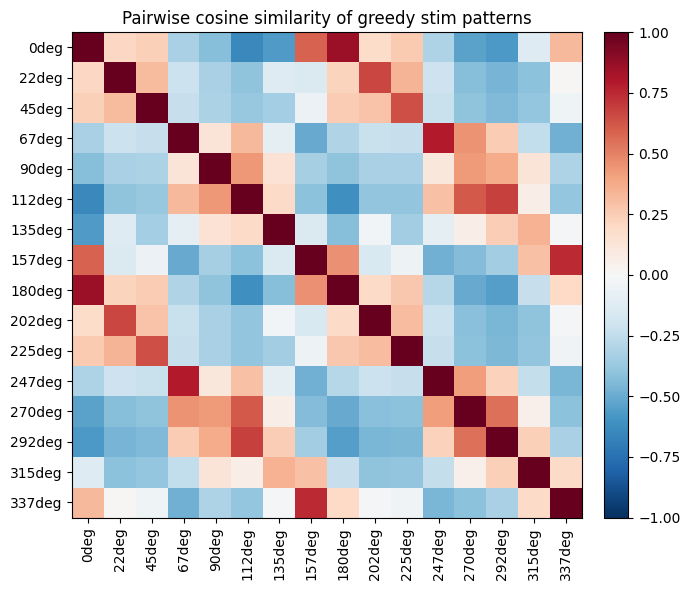

unique stim patterns (exact): 16 / 16
exact-match pairs: 0
mean off-diagonal cosine sim: -0.066


In [93]:
# Pairwise cosine similarity of greedy stim patterns across orientations.
from sklearn.preprocessing import normalize
import numpy as np 
stim_flat = np.stack([s.flatten() for s in est_stims], axis=0)  # (n_orient, n_ch * n_bins)
stim_flat = stim_flat - stim_flat.mean(axis=0, keepdims=True)  # zero-center for cosine similarity
stim_normed = normalize(stim_flat, norm='l2')
sim_stim = stim_normed @ stim_normed.T  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_stim, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of greedy stim patterns')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Quick uniqueness summary.
n_orient = len(est_stims)
exact_matches = sum(
    1 for i in range(n_orient) for j in range(i + 1, n_orient)
    if np.array_equal(est_stims[i], est_stims[j])
)

unique_count = len({s.tobytes() for s in est_stims})
print(f'unique stim patterns (exact): {unique_count} / {n_orient}')
print(f'exact-match pairs: {exact_matches}')
print(f'mean off-diagonal cosine sim: {sim_stim[np.triu_indices(n_orient, k=1)].mean():.3f}')


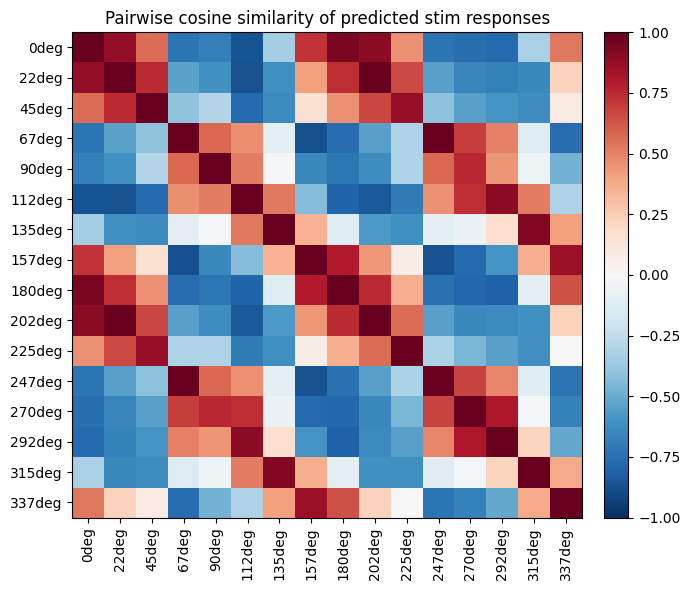

In [94]:
# cosine similarity of predicted stim response vectors 
pred_responses = []
for created_stim in est_stims:
    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,)
    pred_responses.append(pred_counts)
pred_responses = np.stack(pred_responses, axis=0)   # (n_orient, n_neurons)
pred_responses_normed = normalize(pred_responses - np.mean(pred_responses, axis=0), norm='l2')
sim_pred_resp = pred_responses_normed @ pred_responses_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_pred_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of predicted stim responses')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pairwise cosine similarity of actual target responses 600 ms')

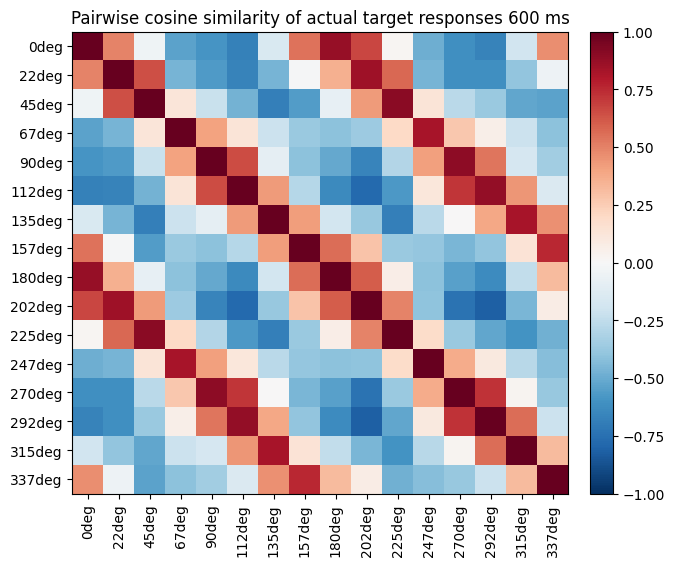

In [95]:
# pairwise cosine similarity of target response vectors (for reference)
targets_normed = normalize(targets - np.mean(targets, axis=0), norm='l2')
sim_target_resp = targets_normed @ targets_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))          
im = ax.imshow(sim_target_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
ax.set_title(f'Pairwise cosine similarity of actual target responses {VIS_ORIENT_TIME} ms')          

In [99]:
# Project everything (observed averages, per-trial dots, CNN predictions) into a
# shared (CIS, PC1, PC2) space built from the SAME VIS_ORIENT_TIME window used
# to define the targets, so all three live on a common scale.
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Rebuild the projection from `targets` (== sum_responses windowed to VIS_ORIENT_TIME).
X_win        = targets                                      # (n_orient, n_neurons)
mean_vec_win = X_win.mean(axis=0, keepdims=True)
pca_win      = PCA(n_components=2).fit(X_win)
proj_win, _  = np.linalg.qr(np.array([
    mean_vec_win[0],
    pca_win.components_[0],
    pca_win.components_[1],
]).T)                                                       # (n_neurons, 3)
coords_win   = X_win @ proj_win                             # (n_orient, 3)

# CNN predictions under greedy stims (already over the VIS_ORIENT_TIME window).
greedy_pred_full = np.zeros((len(visual_orientation_degs), n_neurons), dtype=np.float32)
for o_idx in range(len(visual_orientation_degs)):
    x = torch.from_numpy(est_stims[o_idx]).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))                          # (1, n_neurons, n_bins)
    greedy_pred_full[o_idx] = rate[0, :, :VIS_ORIENT_TIME // 10].sum(dim=1).cpu().numpy()
greedy_coords_win = greedy_pred_full @ proj_win

# Per-trial dots over the same VIS_ORIENT_TIME window.
vis_window_samples = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj_win)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    name='Per-trial', hoverinfo='skip',
))
fig.add_trace(go.Scatter3d(
    x=coords_win[:, 0], y=coords_win[:, 1], z=coords_win[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(title='Orientation (deg)')),
    text=[f'{int(o)}deg' for o in visual_orientation_degs],
    textposition='top center',
    name='Observed orientation avg',
))
fig.add_trace(go.Scatter3d(
    x=greedy_coords_win[:, 0], y=greedy_coords_win[:, 1], z=greedy_coords_win[:, 2],
    mode='markers',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    name='Greedy stim CNN prediction',
))
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter3d(
        x=[coords_win[o, 0], greedy_coords_win[o, 0]],
        y=[coords_win[o, 1], greedy_coords_win[o, 1]],
        z=[coords_win[o, 2], greedy_coords_win[o, 2]],
        mode='lines', line=dict(color='gray', width=2, dash='dot'),
        showlegend=(o == 0), name='match link', hoverinfo='skip',
    ))

fig.update_layout(
    title=f'Observed vs CNN-predicted responses (all over {VIS_ORIENT_TIME} ms window)',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
fig.show()


In [104]:
# ============================================================
# Build pattern registrations directly from est_stims (16 unique patterns,
# 2 steps of 60 ms each). For each step, decode the 6-bin slice on each
# channel into a (channel, delay_mode) entry -- no redistribution.
#
# Hardware constraint: channels are partitioned into 4 equal-sized shanks
# by sorted channel ID, and at most MAX_PER_SHANK channels per shank may
# fire SIMULTANEOUSLY (same bin within a step). Channels with non-overlapping
# delay_mode bin-sets (e.g. dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5})
# don't conflict and may share a shank. Offending channels are flagged and
# dropped to make every (shank, bin) <= MAX_PER_SHANK.
# ============================================================
import pickle
import copy
import itertools
from collections import Counter

K_TRIALS = 10
SHUFFLE_SEED = 0
BINS_PER_STEP = StimCreator.BINS_PER_STEP
STEP_MS = 60
n_bins = est_stims[0].shape[1]
n_steps = n_bins // BINS_PER_STEP
index_to_channel = {idx: ch for ch, idx in channel_to_index.items()}

# ---- Shank partition: 4 equal-sized shanks by sorted channel ID ----
MAX_PER_SHANK = 4
N_SHANKS = 4
sorted_channels = sorted(channel_to_index.keys())
assert len(sorted_channels) % N_SHANKS == 0, (
    f'cannot split {len(sorted_channels)} channels into {N_SHANKS} equal shanks')
shank_size = len(sorted_channels) // N_SHANKS
channel_to_shank = {ch: i // shank_size for i, ch in enumerate(sorted_channels)}
print(f'shanks: {N_SHANKS} x {shank_size} channels  '
      f'(max {MAX_PER_SHANK} simultaneous per shank per bin)')

def slice_to_delay_mode(slice6):
    if not np.any(slice6):
        return None
    for dm, (offsets, amp) in StimCreator._ENCODING_TABLE.items():
        target = np.zeros(BINS_PER_STEP, dtype=np.float32)
        for o in offsets:
            target[o] = amp
        if np.array_equal(slice6, target):
            return dm
    return None

# bin-set per delay_mode -- two channels collide only if these intersect.
DM_BINS = {dm: set(offsets) for dm, (offsets, _amp) in StimCreator._ENCODING_TABLE.items()}

def enforce_shank_limit(cds, ori_idx, step_idx):
    """At most MAX_PER_SHANK channels firing per (shank, bin).

    Walks channels in ascending order; drops a channel if adding it would
    push any (shank, bin) count above the limit. Flags every drop.
    """
    live = {}  # shank -> {bin_idx: count}
    kept, dropped_log = [], []
    for cd in cds:
        shank = channel_to_shank[cd['channel']]
        bins_used = DM_BINS[cd['delay_mode']]
        shank_counts = live.setdefault(shank, {})
        if any(shank_counts.get(b, 0) + 1 > MAX_PER_SHANK for b in bins_used):
            dropped_log.append((shank, cd['channel'], cd['delay_mode']))
            continue
        for b in bins_used:
            shank_counts[b] = shank_counts.get(b, 0) + 1
        kept.append(cd)
    if dropped_log:
        by_shank_drop = {}
        for shank, ch, dm in dropped_log:
            by_shank_drop.setdefault(shank, []).append((ch, dm))
        for shank, items in by_shank_drop.items():
            print(f'[shank-violation] orient {ori_idx} step {step_idx} '
                  f'shank {shank}: dropping {len(items)} channel(s) '
                  f'that exceed {MAX_PER_SHANK} simultaneous: '
                  f'{[(ch, dm) for ch, dm in items]}')
    return kept

# Build canonical step lists straight from each est_stims entry.
unique_patterns = []
for ori_idx, stim in enumerate(est_stims):
    steps_lists = []
    for s in range(n_steps):
        cds = []
        for ch in range(stim.shape[0]):
            sl = stim[ch, s * BINS_PER_STEP:(s + 1) * BINS_PER_STEP]
            dm = slice_to_delay_mode(sl)
            if dm is not None:
                cds.append({'channel': int(index_to_channel[ch]), 'delay_mode': int(dm)})
            elif np.any(sl):
                print(f'[warn] orient {ori_idx} ch {ch} step {s}: unrecognized slice {sl}')
        cds = enforce_shank_limit(cds, ori_idx, s)
        steps_lists.append(cds)
    unique_patterns.append({
        'ori_idx': int(ori_idx),
        'pattern_name': f'50{int(ori_idx)}',
        'steps_lists': steps_lists,
    })

# Expand to K_TRIALS each, shuffle to interleave.
rng = np.random.default_rng(SHUFFLE_SEED)
trial_slots = [(p['ori_idx'], p['pattern_name']) for p in unique_patterns for _ in range(K_TRIALS)]
order = rng.permutation(len(trial_slots))

generated_patterns = []
for new_pos, slot_idx in enumerate(order):
    ori_idx, pname = trial_slots[slot_idx]
    src = next(p for p in unique_patterns if p['ori_idx'] == ori_idx)
    steps = [
        {'index': step_idx, 'channel_delays': copy.deepcopy(cd), 'start_timestamp': 0}
        for step_idx, cd in enumerate(src['steps_lists'])
    ]
    generated_patterns.append({
        'pattern_name': pname,
        'pattern_lambda': 0.0,
        'pattern_flag_start_timestamp': 0,
        'pattern_timing_index': new_pos + 1,
        'steps': steps,
    })

# ---- Final per-bin shank-limit assertion (post-drop, must always pass) ----
for p in generated_patterns:
    for s in p['steps']:
        per_shank_bin = {}  # (shank, bin) -> count
        for cd in s['channel_delays']:
            shank = channel_to_shank[cd['channel']]
            for b in DM_BINS[cd['delay_mode']]:
                key = (shank, b)
                per_shank_bin[key] = per_shank_bin.get(key, 0) + 1
        for (shank, b), n in per_shank_bin.items():
            assert n <= MAX_PER_SHANK, (
                f'pattern {p["pattern_name"]} step {s["index"]} shank {shank} '
                f'bin {b}: {n} > {MAX_PER_SHANK} after drop -- bug in enforce_shank_limit')
print(f'[OK] all {len(generated_patterns)} trials respect <={MAX_PER_SHANK} simultaneous per shank per bin')

out_path = 'data/generated_pattern_registration.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(generated_patterns, f)
print(f'Wrote {len(generated_patterns)} trials ({len(unique_patterns)} unique patterns x {K_TRIALS}) to {out_path}')

# ---- Schema validation against the reference file ----
with open(f'{DATADIR}/Combined_Pattern_Registrations.pkl', 'rb') as f:
    ref = pickle.load(f)
ref_keys = set(ref[0].keys()); gen_keys = set(generated_patterns[0].keys())
assert ref_keys == gen_keys, f'top-level keys differ: ref-only={ref_keys-gen_keys}, gen-only={gen_keys-ref_keys}'
ref_step_keys = set(ref[0]['steps'][0].keys()); gen_step_keys = set(generated_patterns[0]['steps'][0].keys())
assert ref_step_keys == gen_step_keys, 'step keys differ'
print('[OK] schema matches Combined_Pattern_Registrations.pkl')

# ---- Trial / timing-index sanity ----
timing_idxs = [p['pattern_timing_index'] for p in generated_patterns]
assert len(set(timing_idxs)) == len(timing_idxs)
assert sorted(timing_idxs) == list(range(1, len(generated_patterns) + 1))
name_counts = Counter(p['pattern_name'] for p in generated_patterns)
assert all(c == K_TRIALS for c in name_counts.values()), f'unequal trial counts: {name_counts}'
names_in_order = [p['pattern_name'] for p in generated_patterns]
max_run = max(len(list(g)) for _, g in itertools.groupby(names_in_order))
print(f'[OK] {len(set(timing_idxs))} distinct timing idxs, {K_TRIALS} trials/pattern, '
      f'longest same-pattern run = {max_run}')

# ---- Round-trip via read_pattern_json ----
rt_df = read_pattern_json(out_path)
print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
      f'{rt_df["pattern_timing_index"].nunique()} timing idxs, '
      f'{rt_df["pattern_name"].nunique()} unique patterns')

# ---- Verify each generated pattern reproduces its est_stims when re-encoded ----
# (After shank-drop the rebuilt stim may differ from est_stims on dropped
# channels, so this only round-trips when no drops occurred.)
n_mismatch = 0
for p in generated_patterns:
    ori_idx = int(p['pattern_name'][2:])
    rebuilt = np.zeros_like(est_stims[ori_idx])
    for s in p['steps']:
        s_idx = s['index']
        for cd in s['channel_delays']:
            ch_idx = channel_to_index[cd['channel']]
            offsets, amp = StimCreator._ENCODING_TABLE[cd['delay_mode']]
            for o in offsets:
                rebuilt[ch_idx, s_idx * BINS_PER_STEP + o] = amp
    if not np.array_equal(rebuilt, est_stims[ori_idx]):
        n_mismatch += 1
if n_mismatch == 0:
    print('[OK] every generated pattern re-encodes to its est_stims slice')
else:
    print(f'[note] {n_mismatch} patterns differ from est_stims due to shank-limit drops')


shanks: 4 x 10 channels  (max 4 simultaneous per shank per bin)
[OK] all 160 trials respect <=4 simultaneous per shank per bin
Wrote 160 trials (16 unique patterns x 10) to data/generated_pattern_registration.pkl
[OK] schema matches Combined_Pattern_Registrations.pkl
[OK] 160 distinct timing idxs, 10 trials/pattern, longest same-pattern run = 2
[OK] read_pattern_json round-trip: 1550 rows, 160 timing idxs, 16 unique patterns
[OK] every generated pattern re-encodes to its est_stims slice


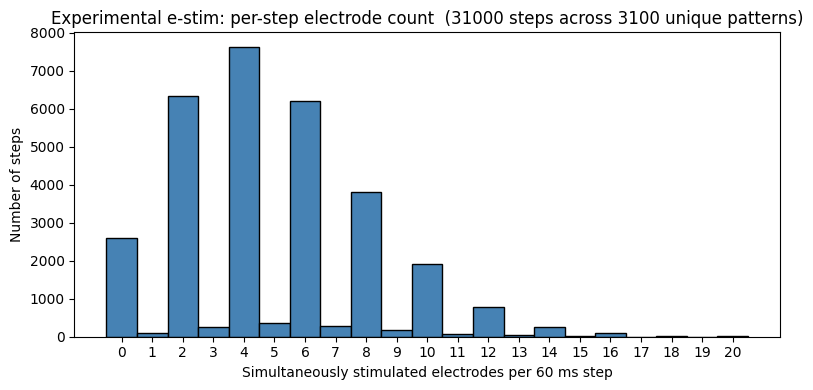

mean = 4.95, median = 4.0, max = 20, n_steps = 31000
(source file has 4000 trial rows, 3100 unique patterns)


In [105]:
# Histogram: number of simultaneously stimulated electrodes per 60 ms step,
# counted across every step of the EXPERIMENT'S e-stim patterns (the ones used
# to train/val/test the model) -- NOT the greedy reconstructions.
# Source: Combined_Pattern_Registrations.pkl.
# "Simultaneous within a step" = unique channels active anywhere in that step
# (NOT per 10 ms bin), so this is just len(step['channel_delays']).
# Deduplicates to unique pattern_name (3100 unique patterns x 10 steps = 31000)
# rather than counting trial replicates.
import pickle
import matplotlib.pyplot as plt

PATTERN_PKL  = f'{DATADIR}/Combined_Pattern_Registrations.pkl'
DEDUPLICATE  = True  # one entry per unique pattern_name (matches the 3100 figure)

with open(PATTERN_PKL, 'rb') as f:
    experiment_patterns = pickle.load(f)

if DEDUPLICATE:
    seen = {}
    for p in experiment_patterns:
        seen.setdefault(p['pattern_name'], p)
    patterns_to_count = list(seen.values())
else:
    patterns_to_count = experiment_patterns

per_step_counts = np.array([
    len(s['channel_delays'])
    for p in patterns_to_count
    for s in p['steps']
])

max_count = int(per_step_counts.max()) if len(per_step_counts) else 0
bins = np.arange(-0.5, max_count + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_step_counts, bins=bins, color='steelblue', edgecolor='black')
ax.set_xlabel('Simultaneously stimulated electrodes per 60 ms step')
ax.set_ylabel('Number of steps')
ax.set_title(f'Experimental e-stim: per-step electrode count  '
             f'({len(per_step_counts)} steps across {len(patterns_to_count)} '
             f'{"unique patterns" if DEDUPLICATE else "trials"})')
ax.set_xticks(np.arange(0, max_count + 1))
plt.tight_layout()
plt.show()

print(f'mean = {per_step_counts.mean():.2f}, median = {np.median(per_step_counts):.1f}, '
      f'max = {per_step_counts.max()}, n_steps = {len(per_step_counts)}')
print(f'(source file has {len(experiment_patterns)} trial rows, '
      f'{len(set(p["pattern_name"] for p in experiment_patterns))} unique patterns)')


In [112]:
# Explore effect of budget and orientation time on reconstructed results.
# Also collect the CNN-predicted response to each greedy stim so figure 2
# can overlay target vs reconstructed rings per budget.
BUDGETS_SWEEP   = [2, 4, 6, 8, 10, 12, 16]
VIS_TIMES_SWEEP = [60, 120, 240, 300, 420, 600, 720]  # ms

dists_mean       = {}
recon_responses  = {}  # (budget, vis_time) -> (n_orient, n_neurons) CNN pred summed over vis_time
target_responses = {}  # vis_time -> (n_orient, n_neurons) observed averages summed over vis_time

for budget in BUDGETS_SWEEP:
    for vis_time in VIS_TIMES_SWEEP:
        print(f'\n=== BUDGET {budget} | VIS_TIME {vis_time} ms ===')
        n_bins_vt = vis_time // 10
        targets = sum_responses[:, :, :n_bins_vt].sum(axis=2)  # (n_orient, n_neurons)
        target_responses[vis_time] = targets

        recon = np.zeros_like(targets, dtype=np.float32)
        distances = []
        for o_idx, orientation in enumerate(visual_orientation_degs):
            target_spikes = targets[o_idx]
            stim_creator = StimCreator(model, device, channel_to_index, n_bins=n_bins_vt, proj=proj)
            created_stim, final_dist = stim_creator.create_stim(
                target_spikes=target_spikes,
                budget_per_step=budget,
                encodings=[-1, 0, 1, 2],
                channels=None,
                require_improvement=True,
                verbose=False,
            )
            distances.append(final_dist)

            # CNN prediction on the greedy stim, integrated over the vis_time window.
            with torch.no_grad():
                x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
                pred = torch.exp(model(x)).cpu().numpy()[0]   # (n_neurons, n_bins_vt)
            recon[o_idx] = pred[:, :n_bins_vt].sum(axis=1)

        recon_responses[(budget, vis_time)] = recon
        dists_mean[(budget, vis_time)] = float(np.mean(distances))

print(sorted(dists_mean.items(), key=lambda x: x[1]))



=== BUDGET 2 | VIS_TIME 60 ms ===

=== BUDGET 2 | VIS_TIME 120 ms ===

=== BUDGET 2 | VIS_TIME 240 ms ===

=== BUDGET 2 | VIS_TIME 300 ms ===

=== BUDGET 2 | VIS_TIME 420 ms ===

=== BUDGET 2 | VIS_TIME 600 ms ===

=== BUDGET 2 | VIS_TIME 720 ms ===

=== BUDGET 4 | VIS_TIME 60 ms ===

=== BUDGET 4 | VIS_TIME 120 ms ===

=== BUDGET 4 | VIS_TIME 240 ms ===

=== BUDGET 4 | VIS_TIME 300 ms ===

=== BUDGET 4 | VIS_TIME 420 ms ===

=== BUDGET 4 | VIS_TIME 600 ms ===

=== BUDGET 4 | VIS_TIME 720 ms ===

=== BUDGET 6 | VIS_TIME 60 ms ===

=== BUDGET 6 | VIS_TIME 120 ms ===

=== BUDGET 6 | VIS_TIME 240 ms ===

=== BUDGET 6 | VIS_TIME 300 ms ===

=== BUDGET 6 | VIS_TIME 420 ms ===

=== BUDGET 6 | VIS_TIME 600 ms ===

=== BUDGET 6 | VIS_TIME 720 ms ===

=== BUDGET 8 | VIS_TIME 60 ms ===

=== BUDGET 8 | VIS_TIME 120 ms ===

=== BUDGET 8 | VIS_TIME 240 ms ===

=== BUDGET 8 | VIS_TIME 300 ms ===

=== BUDGET 8 | VIS_TIME 420 ms ===

=== BUDGET 8 | VIS_TIME 600 ms ===

=== BUDGET 8 | VIS_TIME 720 ms 

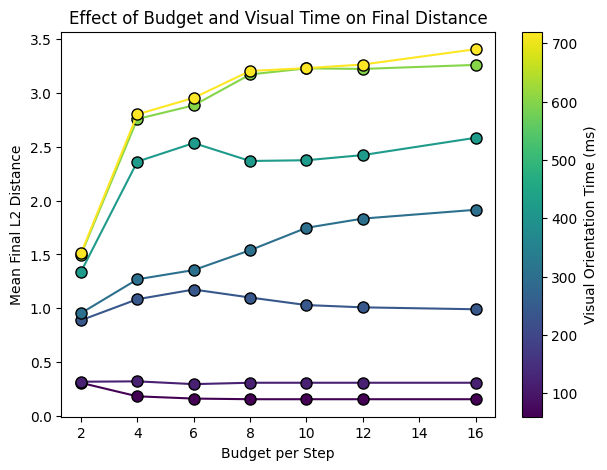

In [113]:
# Mean L2 distance vs budget, one line per vis_time (colored by vis_time).
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

vis_times = sorted({k[1] for k in dists_mean.keys()})
norm = Normalize(vmin=min(vis_times), vmax=max(vis_times))

fig, ax = plt.subplots(figsize=(7, 5))
for vt in vis_times:
    pts = sorted([(k[0], v) for k, v in dists_mean.items() if k[1] == vt])
    budgets = [p[0] for p in pts]
    dists   = [p[1] for p in pts]
    ax.plot(budgets, dists, '-o', color=viridis(norm(vt)),
            markeredgecolor='black', markersize=8, linewidth=1.5,
            label=f'{vt} ms')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Visual Orientation Time (ms)')
ax.set_xlabel('Budget per Step')
ax.set_ylabel('Mean Final L2 Distance')
ax.set_title('Effect of Budget and Visual Time on Final Distance')
plt.show()


In [114]:
# 3D plotly: rings of orientation responses at increasing integration windows,
# with longitudinal lines connecting matching orientations across rings so the
# stack looks like a cone.
# Uses the same (CIS, PC1, PC2) projection `proj` built in cell 6.
import plotly.graph_objects as go

RING_MARKER_SZ  = {60: 3, 120: 4, 240: 5, 300: 5, 420: 6, 600: 8, 720: 10}
RING_SYMBOLS    = {60: 'circle', 120: 'circle', 240: 'circle', 300: 'diamond', 420: 'diamond', 600: 'square', 720: 'square'}
doubled         = (np.array(visual_orientation_degs) * 2) % 360

ring_pts = {}  # vis_time -> (n_orient, 3) projected points

fig = go.Figure()
for vis_time in vis_times:
    targets_vt   = sum_responses[:, :, :vis_time // 10].sum(axis=2)   # (n_orient, n_neurons)
    targets_proj = targets_vt @ proj                                  # (n_orient, 3)
    ring_pts[vis_time] = targets_proj

    # Close the ring by repeating the first point.
    xs = np.concatenate([targets_proj[:, 0], targets_proj[:1, 0]])
    ys = np.concatenate([targets_proj[:, 1], targets_proj[:1, 1]])
    zs = np.concatenate([targets_proj[:, 2], targets_proj[:1, 2]])

    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='lines',
        line=dict(color='lightgray', width=2),
        showlegend=False, hoverinfo='skip',
    ))
    fig.add_trace(go.Scatter3d(
        x=targets_proj[:, 0], y=targets_proj[:, 1], z=targets_proj[:, 2],
        mode='markers',
        marker=dict(
            size=RING_MARKER_SZ[vis_time],
            symbol=RING_SYMBOLS[vis_time],
            color=doubled, colorscale='HSV', cmin=0, cmax=360,
            line=dict(color='black', width=1),
            colorbar=(dict(
                title='Orientation (deg)',
                tickvals=np.arange(0, 361, 72),
                ticktext=[f'{int(v/2)}deg' for v in np.arange(0, 361, 72)],
            ) if vis_time == vis_times[0] else None),
        ),
        name=f'{vis_time} ms',
        text=[f'{int(o)}deg, {vis_time} ms' for o in visual_orientation_degs],
        hovertemplate='%{text}<extra></extra>',
    ))

# Longitudinal "cone" lines: for each orientation, connect its point across
# all vis_times in order. One Scatter3d trace per orientation, colored by
# the doubled-orientation HSV value so spokes match the ring colors.
sorted_vts = sorted(vis_times)
import plotly.colors as pc
hsv_scale = pc.get_colorscale('HSV')
for o_idx in range(len(visual_orientation_degs)):
    xs = [ring_pts[vt][o_idx, 0] for vt in sorted_vts]
    ys = [ring_pts[vt][o_idx, 1] for vt in sorted_vts]
    zs = [ring_pts[vt][o_idx, 2] for vt in sorted_vts]
    spoke_color = pc.sample_colorscale(hsv_scale, doubled[o_idx] / 360.0)[0]
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='lines',
        line=dict(color=spoke_color, width=2),
        opacity=0.6,
        showlegend=False, hoverinfo='skip',
    ))

fig.update_layout(
    title='Orientation rings vs integration window (visual response data only)',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
fig.show()


In [115]:
# Figure 2: target vs reconstructed rings, with a dropdown over vis_time.
# Coloring within a vis_time:
#   - target ring: HSV by orientation (same scheme as figure 1), dashed-black closing line
#   - each budget's recon ring: one solid color per budget, NO connecting line
# All reconstructed rings use the same marker size; only color encodes budget.
import plotly.graph_objects as go
import plotly.colors as pc

VIS_TIMES_FIG2 = VIS_TIMES_SWEEP
BUDGETS_FIG2   = BUDGETS_SWEEP
doubled        = (np.array(visual_orientation_degs) * 2) % 360

# One color per budget, sampled from viridis so budget order is meaningful.
BUDGET_COLORS = pc.sample_colorscale(
    'Viridis', np.linspace(0.05, 0.95, len(BUDGETS_FIG2))
)
RECON_MARKER_SIZE = 6

fig = go.Figure()
trace_groups = []  # one list of trace indices per vis_time

for vi, vis_time in enumerate(VIS_TIMES_FIG2):
    group = []

    # --- Target ring: dashed-black closing line + HSV-by-orientation markers ---
    tgt = target_responses[vis_time] @ proj  # (n_orient, 3)
    xs = np.concatenate([tgt[:, 0], tgt[:1, 0]])
    ys = np.concatenate([tgt[:, 1], tgt[:1, 1]])
    zs = np.concatenate([tgt[:, 2], tgt[:1, 2]])
    group.append(len(fig.data))
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs, mode='lines',
        line=dict(color='black', width=2, dash='dash'),
        showlegend=False, hoverinfo='skip',
    ))
    target_marker = dict(
        size=9, symbol='circle',
        color=doubled, colorscale='HSV', cmin=0, cmax=360,
        line=dict(color='black', width=0.8),
    )
    if vi == 0:
        target_marker['colorbar'] = dict(
            title='Target orientation (deg)',
            tickvals=np.arange(0, 361, 72),
            ticktext=[f'{int(v/2)}deg' for v in np.arange(0, 361, 72)],
        )
    group.append(len(fig.data))
    fig.add_trace(go.Scatter3d(
        x=tgt[:, 0], y=tgt[:, 1], z=tgt[:, 2],
        mode='markers', marker=target_marker,
        name='target',
        text=[f'{int(o)}deg | target' for o in visual_orientation_degs],
        hovertemplate='%{text}<extra></extra>',
        showlegend=True,
    ))

    # --- Reconstructed rings: markers only, one solid color per budget ---
    for bi, budget in enumerate(BUDGETS_FIG2):
        recon = recon_responses[(budget, vis_time)] @ proj
        group.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=recon[:, 0], y=recon[:, 1], z=recon[:, 2],
            mode='markers',
            marker=dict(
                size=RECON_MARKER_SIZE,
                color=BUDGET_COLORS[bi],
                line=dict(color='black', width=0.5),
            ),
            name=f'recon b={budget}',
            text=[f'{int(o)}deg | recon b={budget}' for o in visual_orientation_degs],
            hovertemplate='%{text}<extra></extra>',
            showlegend=True,
        ))

    trace_groups.append(group)

# Dropdown toggles which vis_time group is visible.
n_traces = len(fig.data)
buttons = []
for vi, vis_time in enumerate(VIS_TIMES_FIG2):
    visible = [False] * n_traces
    for idx in trace_groups[vi]:
        visible[idx] = True
    buttons.append(dict(
        label=f'{vis_time} ms', method='update',
        args=[{'visible': visible},
              {'title': f'Target vs reconstructed rings  -  vis_time = {vis_time} ms'}],
    ))

# Default: show the first vis_time only.
for ti in range(n_traces):
    fig.data[ti].visible = ti in trace_groups[0]

fig.update_layout(
    title=f'Target vs reconstructed rings  -  vis_time = {VIS_TIMES_FIG2[0]} ms',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=950, height=750,
    updatemenus=[dict(
        type='dropdown', x=0.0, y=1.12, xanchor='left', yanchor='top',
        showactive=True, buttons=buttons,
    )],
    annotations=[dict(
        x=0.0, y=1.16, xref='paper', yref='paper', xanchor='left',
        text='vis_time:', showarrow=False,
    )],
)
fig.show()


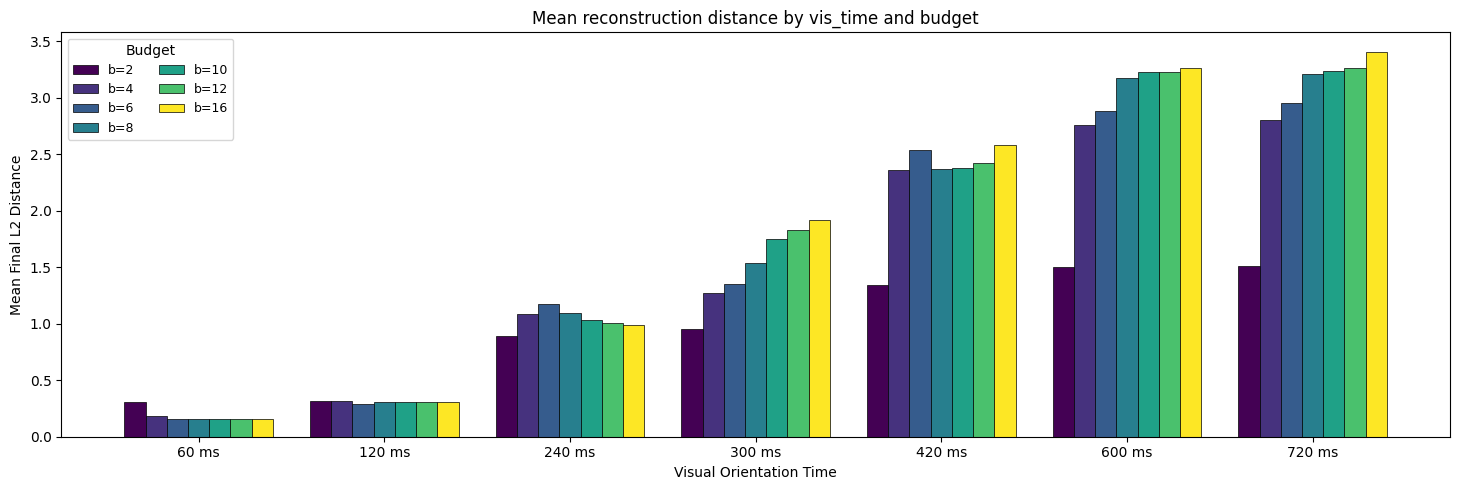

In [116]:
# Grouped bar chart: mean L2 distance, grouped by vis_time, bars colored by budget.
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

vis_times_sorted = sorted({k[1] for k in dists_mean.keys()})
budgets_sorted   = sorted({k[0] for k in dists_mean.keys()})
norm = Normalize(vmin=min(budgets_sorted), vmax=max(budgets_sorted))

n_groups = len(vis_times_sorted)
n_bars   = len(budgets_sorted)
group_x  = np.arange(n_groups)
bar_w    = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(max(8, 1.2 * n_groups * n_bars / 4), 5))
for bi, budget in enumerate(budgets_sorted):
    heights = [dists_mean.get((budget, vt), np.nan) for vt in vis_times_sorted]
    offsets = group_x + (bi - (n_bars - 1) / 2) * bar_w
    ax.bar(offsets, heights, width=bar_w,
           color=viridis(norm(budget)), edgecolor='black', linewidth=0.5,
           label=f'b={budget}')

ax.set_xticks(group_x)
ax.set_xticklabels([f'{vt} ms' for vt in vis_times_sorted])
ax.set_xlabel('Visual Orientation Time')
ax.set_ylabel('Mean Final L2 Distance')
ax.set_title('Mean reconstruction distance by vis_time and budget')
ax.legend(title='Budget', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
